# Code for controlling laser and oscilloscope

## Initialization

In [19]:
import pyvisa
import time
import numpy as np
import time

In [21]:
SCOPE_IP = "10.210.30.243"

def connect_scope():
    """
    Connect to Rigol DHO4404 oscilloscope.
    Returns a PyVISA instrument object.
    """

    rm = pyvisa.ResourceManager("@py")

    scope = rm.open_resource(
        f"TCPIP0::{SCOPE_IP}::INSTR"
    )

    scope.timeout = 10000  # ms

    idn = scope.query("*IDN?").strip()

    print(f"Connected: {idn}")

    return scope


In [22]:
import time
import numpy as np


def acquire_waveform(scope, channel="CHAN1"):

    # Stop acquisition
    scope.write(":STOP")

    time.sleep(0.2)

    # Configure waveform transfer
    scope.write(f":WAV:SOUR {channel}")
    scope.write(":WAV:MODE RAW")
    scope.write(":WAV:FORM BYTE")

    # Scaling factors
    y_inc = float(scope.query(":WAV:YINC?"))
    y_org = float(scope.query(":WAV:YOR?"))
    y_ref = float(scope.query(":WAV:YREF?"))

    x_inc = float(scope.query(":WAV:XINC?"))
    x_org = float(scope.query(":WAV:XOR?"))

    sample_rate = 1.0 / x_inc

    print(f"x_inc = {x_inc:.3e} s")
    print(f"sample rate = {sample_rate/1e6:.2f} MSa/s")

    raw = scope.query_binary_values(
        ":WAV:DATA?",
        datatype="B",
        container=np.array
    )

    print("Downloaded points:", len(raw))

    if len(raw) == 0:

        scope.write(":RUN")

        raise RuntimeError(
            "Scope returned empty waveform."
        )

    voltage = (
        (raw.astype(np.float64) - y_ref)
        * y_inc
        + y_org
    )

    time_axis = (
        np.arange(len(voltage))
        * x_inc
        + x_org
    )

    acquisition_time = len(voltage) / sample_rate

    print(
        f"Acquisition length = "
        f"{acquisition_time:.6f} s"
    )

    # Resume acquisition
    scope.write(":RUN")

    time.sleep(1.2)

    return {
        "signal": voltage,
        "time": time_axis,
        "sample_rate": sample_rate,
        "acquisition_time": acquisition_time,
        "channel": channel,
    }

In [23]:
scope = connect_scope()

Connected: RIGOL TECHNOLOGIES,DHO4404,HDO4A263600855,00.02.13


### Data acquisition

In [86]:
from pathlib import Path

SAVE_FOLDER = Path("/Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/PMT=0.85")

SAVE_FOLDER.mkdir(exist_ok=True)

In [87]:
repeat = 10

for i in range(repeat):

    print(f"Waiting for trigger {i+1}/{repeat}")

    waveform = acquire_waveform(
        scope,
        channel="CHAN1"
    )

    filename = SAVE_FOLDER / f"data_{i+1:03d}.npz"

    np.savez(
        filename,
        signal=waveform["signal"],
        sample_rate=waveform["sample_rate"],
        acquisition_time=waveform["acquisition_time"],
        channel=waveform["channel"]
    )

    print(f"Saved: {filename}")

Waiting for trigger 1/10
x_inc = 1.000e-07 s
sample rate = 10.00 MSa/s
Downloaded points: 10000000
Acquisition length = 1.000000 s
Saved: /Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/PMT=0.85/data_001.npz
Waiting for trigger 2/10


VisaIOError: VI_ERROR_IO (-1073807298): Could not perform operation because of I/O error.

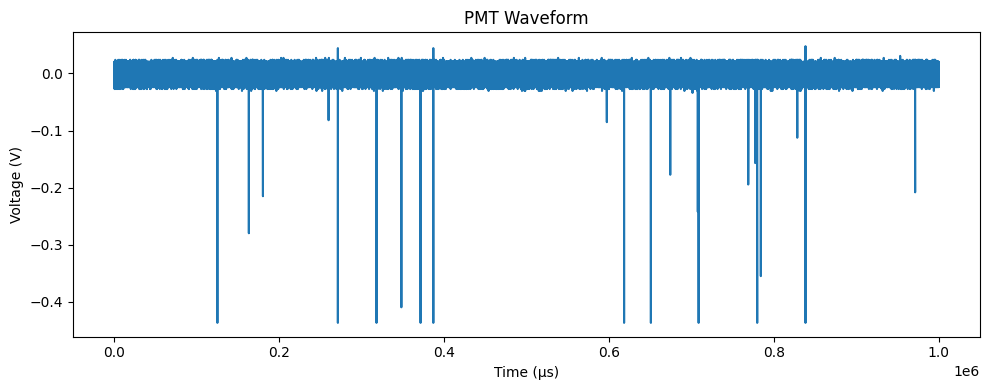

In [2]:
import numpy as np
import matplotlib.pyplot as plt

file = "/Users/zipeiwu/Desktop/BU/lab/projects/imaging/single_photon_counting/scope/notrigger/PMT=0.8/data_001.npz"

data = np.load(file)

signal = data["signal"]
sample_rate = float(data["sample_rate"])

time = np.arange(len(signal)) / sample_rate

plt.figure(figsize=(10,4))
plt.plot(time * 1e6, signal)

plt.xlabel("Time (µs)")
plt.ylabel("Voltage (V)")
plt.title("PMT Waveform")
plt.tight_layout()

plt.show()